# Klasifikacija žanra filma na osnovu teksta

| # | Model | Poreklo |
|---|-------|---------|
| 1 | GloVe (prosek) + MLP 300→50→13 | **replikacija rada** |
| 2 | TF-IDF + Logistička regresija | naše |
| 3 | MiniLM embedinzi + LogReg | naše |

## 1. Priprema

In [38]:
import time, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from helpers import (load_split, clean_plot, GENRES, evaluate, per_genre_ap,
                    tune_thresholds, results_table, PAPER_RESULTS,
                    load_glove, glove_encode)

RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

Path("models").mkdir(exist_ok=True)

In [39]:
train = load_split("train")
val   = load_split("val")
test  = load_split("test")

X_train = clean_plot(train["plot"])
X_val = clean_plot(val["plot"])
X_test = clean_plot(test["plot"])

y_train, y_val, y_test = train[GENRES].values, val[GENRES].values, test[GENRES].values

print(f"train {len(train):5d}   val {len(val):5d}   test {len(test):5d}")

train  3454   val   491   test   989


## 2. Kratka analiza podataka

Koliko je skup neizbalansiran, koliko žanrova ima film, kolika je dužina tekstova.

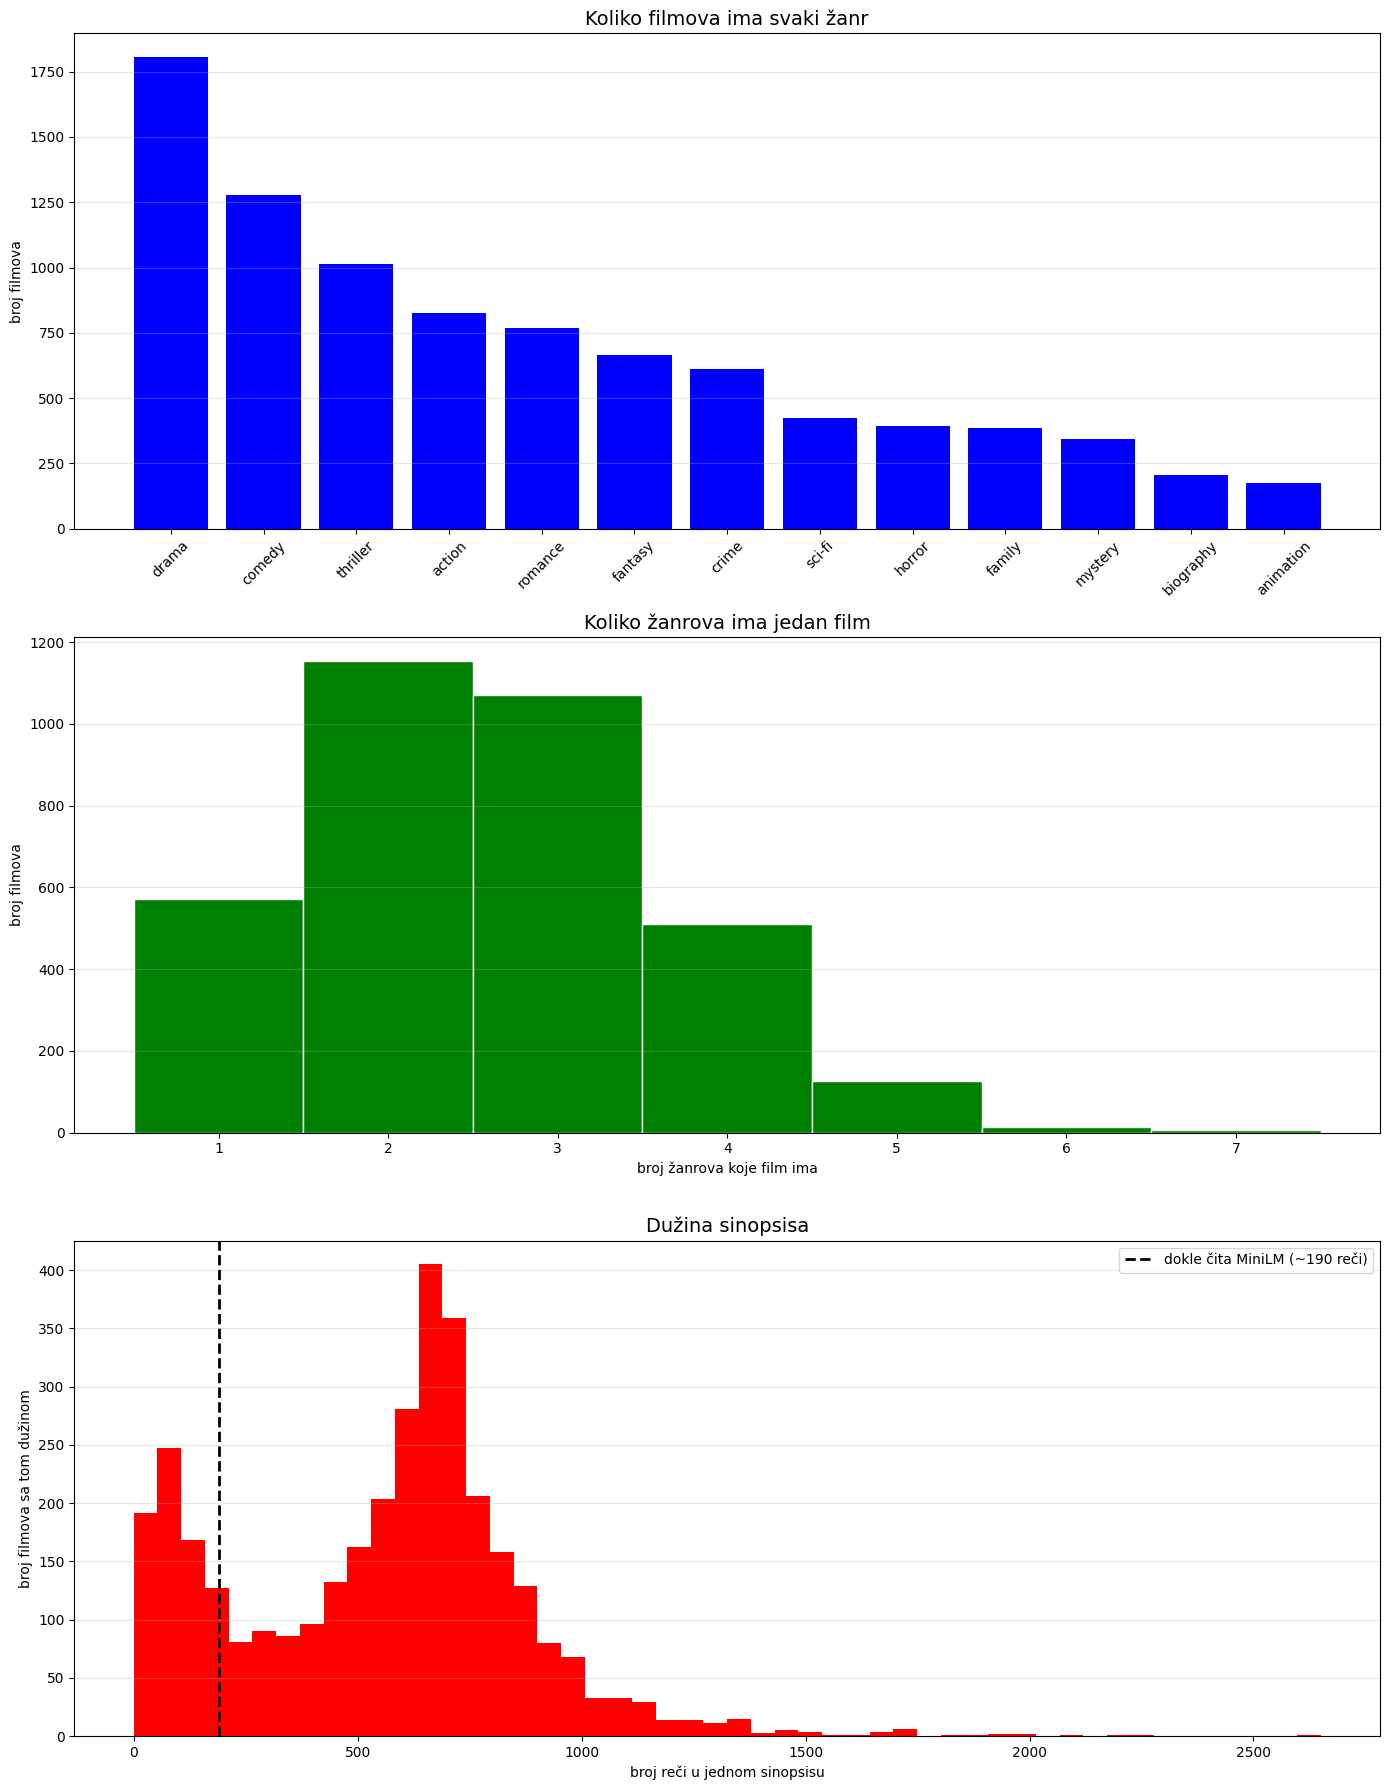

prosečno žanrova po filmu : 2.58
medijana dužine sinopsisa : 613 reči
najčešći/najređi žanr      : 1806/175 = 10.3x razlike
kod 80% filmova MiniLM preskoči većinu teksta


In [40]:
fig, ax = plt.subplots(3, 1, figsize=(14, 18))

# (a) koliko filmova ima svaki zanr
counts = train[GENRES].sum().sort_values(ascending=False)
ax[0].bar(counts.index, counts.values, color="blue")
ax[0].set_title("Koliko filmova ima svaki žanr", fontsize=14)
ax[0].set_ylabel("broj filmova")
ax[0].tick_params(axis="x", rotation=45)
ax[0].grid(axis="y", alpha=0.3)

# (b) koliko zanrova ima jedan film
per_movie = train[GENRES].sum(axis=1)
ax[1].hist(per_movie, bins=range(1, per_movie.max() + 2), align="left",
           color="green", edgecolor="white")
ax[1].set_title("Koliko žanrova ima jedan film", fontsize=14)
ax[1].set_xlabel("broj žanrova koje film ima")
ax[1].set_ylabel("broj filmova")
ax[1].grid(axis="y", alpha=0.3)

# (c) duzina sinopsisa
# x = koliko reci ima sinopsis, y = koliko filmova ima sinopsis te duzine
lens = train["plot"].fillna("").str.split().str.len()
ax[2].hist(lens, bins=50, color="red")
ax[2].axvline(190, color="black", ls="--", lw=2,
              label="dokle čita MiniLM (~190 reči)")
ax[2].set_title("Dužina sinopsisa", fontsize=14)
ax[2].set_xlabel("broj reči u jednom sinopsisu")
ax[2].set_ylabel("broj filmova sa tom dužinom")
ax[2].legend()
ax[2].grid(axis="y", alpha=0.3)

plt.tight_layout()
plt.show()

print(f"prosečno žanrova po filmu : {per_movie.mean():.2f}")
print(f"medijana dužine sinopsisa : {int(lens.median())} reči")
print(f"najčešći/najređi žanr      : {counts.max()}/{counts.min()} = {counts.max()/counts.min():.1f}x razlike")
print(f"kod {(lens > 190).mean()*100:.0f}% filmova MiniLM preskoči većinu teksta")

**Zapažanja:**

- Skup je jako neizbalansiran — `drama` ima ~10x više primera od `animation`.
  Zato svuda koristimo težine klasa, a kao glavnu metriku gledamo **macro** AP
  koja svaki žanr broji podjednako.
- Film ima u proseku 2.6 žanra — potvrda da je zadatak multi-label.
- **Medijana sinopsisa je ~600 reči.** Ovaj broj će kasnije objasniti zašto
  MiniLM podbacuje.

---
# Deo I — Replikacija modela iz rada

Iz rada (odeljak 4, str. 3):

> *"The plot summaries were truncated to max 3000 word length, then transformed
> into a 1x300 vector using the GloVe 42B CommonCrawl embedding. Outputs were
> produced using a 300x50, and 50x13 fully-connected layers."*

Plus, iz istog odeljka: BCE sa težinama pozitivnih primera, sigmoid na izlazu,
Adam optimizator, batch 64, early stopping po validacionoj grešci.

**Jedno odstupanje:** rad koristi GloVe **42B CommonCrawl** (5 GB). Mi koristimo
**6B Wikipedia+Gigaword** (1 GB) jer je 5x manji, a razlika u kvalitetu je mala.
Ovo je zabeleženo u zaključcima.

### 4.1 GloVe embedinzi

In [41]:
t0 = time.time()
vocab, emb = load_glove()          # data/glove/glove.6B.300d.txt
print(f"GloVe: {len(vocab)} reči x {emb.shape[1]} dimenzija  ({time.time()-t0:.0f}s)")

GloVe: 400001 reči x 300 dimenzija  (32s)


Svaka reč je tačka u prostoru od 300 dimenzija, gde su slične reči blizu.
Rad ceo sinopsis svodi na **jedan** vektor tako što izračuna prosek vektora svih reči.

To je snažno ograničenje: računanje proseka briše redosled reči, a retke reči
(*zombie*, *spaceship*) se utope među stotinama čestih. Baš su te retke reči
one koje odaju žanr.

In [42]:
t0 = time.time()
X_train_glove = glove_encode(X_train, vocab, emb)    # skraćivanje na 3000 reči + prosek
X_val_glove = glove_encode(X_val, vocab, emb)
X_test_glove = glove_encode(X_test, vocab, emb)
print(f"izračunato za {time.time()-t0:.0f}s  |  oblik: {X_train_glove.shape}")
print(f"\ncelih {int(train['plot'].fillna('').str.split().str.len().median())} reči teksta -> svega 300 brojeva")

izračunato za 3s  |  oblik: (3454, 300)

celih 613 reči teksta -> svega 300 brojeva



celih 613 reči teksta -> svega 300 brojeva


### 4.2 Mreža 300 → 50 → 13

In [43]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset

torch.manual_seed(RANDOM_STATE)


class TextGenreModel(nn.Module):
    """Mreza iz rada: dva potpuno povezana sloja, 300 -> 50 -> 13."""

    def __init__(self, input_size=300, hidden_size=50, output_size=13):
        super(TextGenreModel, self).__init__()
        self.fc1 = nn.Linear(input_size, hidden_size)
        self.relu1 = nn.ReLU()
        self.fc2 = nn.Linear(hidden_size, output_size)

    def forward(self, x):
        x = self.relu1(self.fc1(x))
        x = self.fc2(x)
        return x


pos_weight = torch.tensor((len(y_train) - y_train.sum(0)) / y_train.sum(0),
                          dtype=torch.float32)

print("tezine po zanru:")
print(pd.Series(pos_weight.numpy().round(1), index=GENRES).to_string())

tezine po zanru:
action        3.200000
animation    18.700001
biography    15.700000
comedy        1.700000
crime         4.700000
drama         0.900000
family        8.000000
fantasy       4.200000
horror        7.700000
mystery       9.000000
romance       3.500000
sci-fi        7.100000
thriller      2.400000


Bez ovih težina model bi naučio da uvek predviđa `drama` i time bio "u pravu"
najveći deo vremena. Rad to eksplicitno navodi kao problem na koji su naišli.

In [44]:
def train_model(X_train_glove, y_train, X_val_glove, y_val,
                epochs=200, patience=20, batch_size=64):
    """Trenira mrezu sa ranim prekidom po validacionoj gresci (kao u radu)."""
    model = TextGenreModel()
    optimizer = optim.Adam(model.parameters())
    criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)

    train_dataset = TensorDataset(torch.tensor(X_train_glove),
                                  torch.tensor(y_train, dtype=torch.float32))
    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

    X_val_tensor = torch.tensor(X_val_glove)
    y_val_tensor = torch.tensor(y_val, dtype=torch.float32)

    history = {"train_loss": [], "val_loss": []}
    best_loss, epochs_without_improvement, best_state = float("inf"), 0, None

    for epoch in range(epochs):
        model.train()
        total_loss = 0.0
        for inputs, labels in train_loader:
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * len(inputs)

        model.eval()
        with torch.no_grad():
            val_loss = criterion(model(X_val_tensor), y_val_tensor).item()

        history["train_loss"].append(total_loss / len(train_dataset))
        history["val_loss"].append(val_loss)

        if epoch % 10 == 0:
            print(f"  epoha {epoch:3d}   trening {history['train_loss'][-1]:.4f}   "
                  f"validacija {val_loss:.4f}")

        if val_loss < best_loss - 1e-4:
            best_loss, epochs_without_improvement = val_loss, 0
            best_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            epochs_without_improvement += 1
            if epochs_without_improvement >= patience:
                print(f"rani prekid na epohi {epoch} "
                      f"(najbolja validaciona greska: {best_loss:.4f})")
                break

    model.load_state_dict(best_state)
    model.eval()
    return model, history


start = time.time()
paper_model, history = train_model(X_train_glove, y_train, X_val_glove, y_val)
print(f"trenirano za {time.time() - start:.0f}s")

  epoha   0   trening 1.1071   validacija 1.0792
  epoha  10   trening 0.7909   validacija 0.7885
  epoha  20   trening 0.7084   validacija 0.7242
  epoha  30   trening 0.6721   validacija 0.7040
  epoha  40   trening 0.6458   validacija 0.6943
  epoha  50   trening 0.6287   validacija 0.6899
  epoha  60   trening 0.6123   validacija 0.6853
  epoha  70   trening 0.5969   validacija 0.6833
  epoha  80   trening 0.5846   validacija 0.6813
  epoha  90   trening 0.5721   validacija 0.6859
  epoha 100   trening 0.5627   validacija 0.6823
rani prekid na epohi 107 (najbolja validaciona greska: 0.6787)
trenirano za 30s


  epoha  10   trening 0.7909   validacija 0.7885


  epoha  20   trening 0.7084   validacija 0.7242


  epoha  30   trening 0.6721   validacija 0.7040


  epoha  40   trening 0.6458   validacija 0.6943


rani prekid na epohi 49 (najbolja validaciona greska: 0.6912)
trenirano za 15s


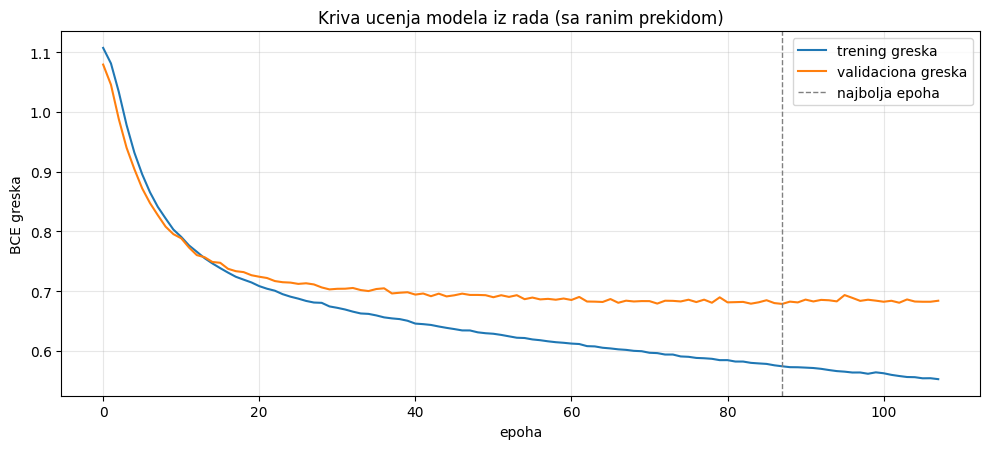

In [45]:
# Kriva ucenja -- odgovara Fig 4 iz rada
fig, ax = plt.subplots(figsize=(10, 4.6))
ax.plot(history["train_loss"], label="trening greska")
ax.plot(history["val_loss"], label="validaciona greska")
ax.axvline(int(np.argmin(history["val_loss"])), ls="--", c="gray", lw=1,
           label="najbolja epoha")
ax.set_xlabel("epoha")
ax.set_ylabel("BCE greska")
ax.set_title("Kriva ucenja modela iz rada (sa ranim prekidom)")
ax.legend()
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [47]:
def predict_probabilities(model, features):
    """Propusti podatke kroz mrezu i vrati verovatnoce (sigmoid nad logitima)."""
    with torch.no_grad():
        return torch.sigmoid(model(torch.tensor(features))).numpy()


score_glove_va = predict_probabilities(paper_model, X_val_glove)
score_glove_te = predict_probabilities(paper_model, X_test_glove)

thresholds_glove = tune_thresholds(y_val, score_glove_va)
replication = evaluate(y_test, score_glove_te, thresholds_glove,
                       "GloVe + MLP (replikacija)")

comparison_with_paper = pd.DataFrame([
    {"izvor": "nasa replikacija",
     **{k: replication[k] for k in ["AP_micro", "AP_macro", "AP_samples"]}},
    {"izvor": "rad (LeBaron)",
     "AP_micro": 0.631661, "AP_macro": 0.619510, "AP_samples": 0.749681},
]).set_index("izvor").round(4)

print("=== REPLIKACIJA vs RAD (test skup) ===")
print(comparison_with_paper.to_string())
print("\nrazlika:", (comparison_with_paper.iloc[0]
                     - comparison_with_paper.iloc[1]).round(4).to_dict())

=== REPLIKACIJA vs RAD (test skup) ===
                  AP_micro  AP_macro  AP_samples
izvor                                           
nasa replikacija    0.6564    0.6619      0.7614
rad (LeBaron)       0.6317    0.6195      0.7497

razlika: {'AP_micro': 0.0247, 'AP_macro': 0.0424, 'AP_samples': 0.0117}


**Replikacija je uspela.** Brojevi su vrlo blizu objavljenih, uz malo odstupanje
naviše — najverovatnije zato što smo popravili pokvareno kodiranje u trećini
sinopsisa i što biramo pragove po žanru.

Time je potvrđeno da naš lanac obrade radi ispravno. Sve što od sada bude bolje
od ovog broja je zasluga **metode**, a ne razlike u podacima.